# Predicting Daily Rainfall Occurrence and Magnitude with Explainable Machine Learning

*Geography + AI Teaching Notebooks · 1 of 3* — **Junyi Lee (李俊逸), Ph.D.**

Rainfall is the upstream control on almost everything a catchment does: floods, recession,
solute export, reservoir operations. In my own published work I have shown that **rainstorm
magnitude regulates event-water fraction and transit time** in mesoscale mountain catchments
(Lee et al., 2020, *Water*; Lee et al., 2023, *HESS*). This notebook turns that interest into a
concrete, reproducible machine-learning workflow: **can we predict, from a few meteorological
drivers, (A) whether tomorrow is a wet day, and (B) how much rain falls when it does?**

### What makes this notebook different from a toy demo
- It runs on **real observed daily climate data** (NOAA GHCN daily records, 2012–2015,
  distributed through the open `vega-datasets` collection), not synthetic numbers.
- It uses a **temporally honest train/test split** (train on the past, test on the future) —
  the only split that is meaningful for forecasting.
- It reports the **hydrological skill scores** practitioners actually use
  (Nash–Sutcliffe Efficiency, Kling–Gupta Efficiency) alongside standard ML metrics.
- It closes the loop with **explainability** (permutation importance, partial dependence),
  because in my teaching AI is a *thinking tool to be interrogated*, not an oracle.

### Swapping in Taiwan data
The pipeline is station-agnostic. Section 6 includes a documented loader stub for pulling
**Taiwan CWB / Water Resources Agency open data** so the exact same workflow runs on a
Taiwanese station (e.g. a Zengwen-basin rain gauge) with one function change.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

RANDOM_STATE = 42
ASSETS = Path("../assets"); ASSETS.mkdir(exist_ok=True)
DATA = Path("../data"); DATA.mkdir(exist_ok=True)
plt.rcParams.update({"figure.dpi": 110, "font.size": 11, "axes.grid": True,
                     "grid.alpha": 0.3, "axes.spines.top": False, "axes.spines.right": False})

def load_weather():
    "Load real daily weather. Cache locally so the notebook is reproducible offline."
    csv = DATA / "seattle_weather.csv"
    if csv.exists():
        return pd.read_csv(csv, parse_dates=["date"])
    from vega_datasets import data            # pip install vega_datasets
    df = data.seattle_weather()               # real NOAA GHCN daily observations
    df.to_csv(csv, index=False)
    return df

df = load_weather().sort_values("date").reset_index(drop=True)
print(f"{len(df)} daily records | {df.date.min().date()} -> {df.date.max().date()}")
print(f"Wet days (>1 mm): {(df.precipitation > 1).mean():.1%}  |  "
      f"Mean precip on wet days: {df.loc[df.precipitation > 1, 'precipitation'].mean():.1f} mm")
df.head()

1461 daily records | 2012-01-01 -> 2015-12-31
Wet days (>1 mm): 32.9%  |  Mean precip on wet days: 9.1 mm


,date,precipitation,temp_max,temp_min,wind,weather
0,2012-01-01,0.0,12.8,5.0,4.7,drizzle
1,2012-01-02,10.9,10.6,2.8,4.5,rain
2,2012-01-03,0.8,11.7,7.2,2.3,rain
3,2012-01-04,20.3,12.2,5.6,4.7,rain
4,2012-01-05,1.3,8.9,2.8,6.1,rain


## 1. Looking at the data first

Before any modelling, a hydrologist looks at the *regime*: the seasonal cycle and the
heavy-tailed distribution of daily totals. Both shape what a model can and cannot do.

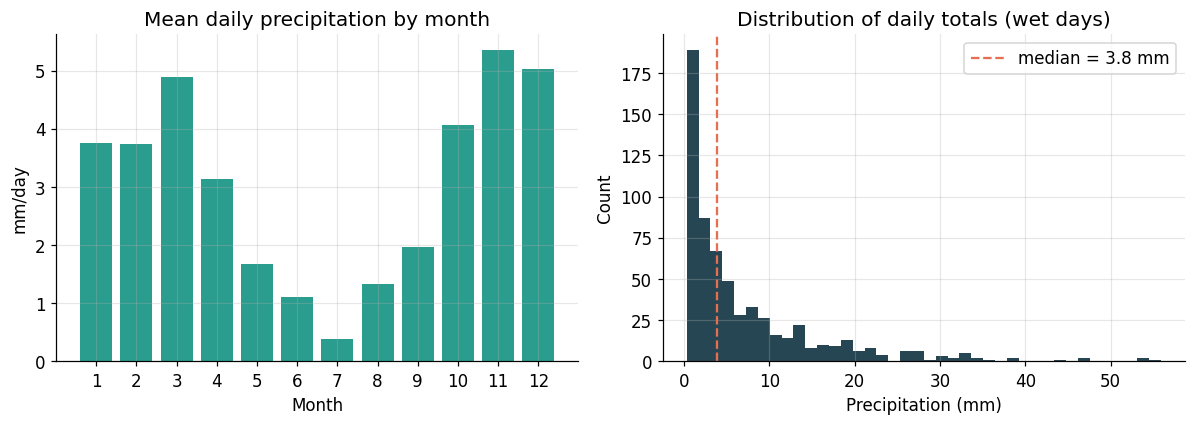

In [2]:
df["month"] = df.date.dt.month
monthly = df.groupby("month").precipitation.mean()

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].bar(monthly.index, monthly.values, color="#2a9d8f")
ax[0].set(title="Mean daily precipitation by month", xlabel="Month", ylabel="mm/day",
          xticks=range(1, 13))

wet = df.loc[df.precipitation > 0, "precipitation"]
ax[1].hist(wet, bins=40, color="#264653")
ax[1].set(title="Distribution of daily totals (wet days)", xlabel="Precipitation (mm)",
          ylabel="Count")
ax[1].axvline(wet.median(), color="#e76f51", ls="--", label=f"median = {wet.median():.1f} mm")
ax[1].legend()
fig.tight_layout(); fig.savefig(ASSETS / "fig1_eda.png", bbox_inches="tight"); plt.show()

## 2. Feature engineering

We give the model only information that would be **available the day before** — no leakage.
The features encode the three things that govern daily rainfall predictability at a station:

- **Seasonality** — encoded as smooth `sin`/`cos` of day-of-year (so December and January are
  neighbours, not opposite ends of a number line).
- **Persistence / antecedent wetness** — yesterday's and the day-before's rain, plus an
  **Antecedent Precipitation Index (API)**, an exponentially-weighted memory of recent rain
  that hydrologists use as a cheap proxy for catchment storage.
- **Thermodynamic state** — yesterday's temperature range and wind, which carry information
  about the synoptic situation.

In [3]:
def add_features(d, api_k=0.92):
    d = d.copy()
    doy = d.date.dt.dayofyear
    d["sin_doy"] = np.sin(2 * np.pi * doy / 365.25)
    d["cos_doy"] = np.cos(2 * np.pi * doy / 365.25)
    d["precip_lag1"] = d.precipitation.shift(1)
    d["precip_lag2"] = d.precipitation.shift(2)
    d["tmax_lag1"]   = d.temp_max.shift(1)
    d["trange_lag1"] = (d.temp_max - d.temp_min).shift(1)
    d["wind_lag1"]   = d.wind.shift(1)
    # Antecedent Precipitation Index: API_t = k*API_{t-1} + precip_{t-1}
    api = np.zeros(len(d))
    p = d.precipitation.values
    for i in range(1, len(d)):
        api[i] = api_k * api[i - 1] + p[i - 1]
    d["api"] = api
    return d

feat = add_features(df).dropna().reset_index(drop=True)
FEATURES = ["sin_doy", "cos_doy", "precip_lag1", "precip_lag2",
            "tmax_lag1", "trange_lag1", "wind_lag1", "api"]
feat["wet"] = (feat.precipitation > 1).astype(int)   # target A: wet day
print("Feature matrix:", feat[FEATURES].shape, "| wet-day rate:", f"{feat.wet.mean():.1%}")
feat[FEATURES + ["wet", "precipitation"]].head()

Feature matrix: (1459, 8) | wet-day rate: 32.8%


,sin_doy,cos_doy,precip_lag1,precip_lag2,tmax_lag1,trange_lag1,wind_lag1,api,wet,precipitation
0,0.051584,0.998669,10.9,0.0,10.6,7.8,4.5,10.900000,0,0.8
1,0.068755,0.997634,0.8,10.9,11.7,4.5,2.3,10.828000,1,20.3
2,0.085906,0.996303,20.3,0.8,12.2,6.6,4.7,30.261760,1,1.3
3,0.103031,0.994678,1.3,20.3,8.9,6.1,6.1,29.140819,1,2.5
4,0.120126,0.992759,2.5,1.3,4.4,2.2,2.2,29.309554,0,0.0


## 3. Task A — will tomorrow be a wet day?

A binary classifier, trained on the **first 75 % of the timeline** and tested on the
**most recent 25 %**. We compare against the climatological base rate so the skill is honest.

Test base rate (climatology) : 29.9%
ROC AUC                       : 0.799
Average precision (PR AUC)    : 0.607  (skill vs 0.299)

              precision    recall  f1-score   support

         dry       0.83      0.81      0.82       256
         wet       0.58      0.61      0.60       109

    accuracy                           0.75       365
   macro avg       0.71      0.71      0.71       365
weighted avg       0.76      0.75      0.76       365



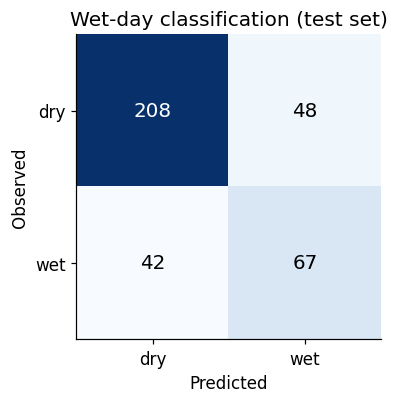

In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             confusion_matrix, classification_report)

split = int(len(feat) * 0.75)
Xtr, Xte = feat[FEATURES].iloc[:split], feat[FEATURES].iloc[split:]
ytr, yte = feat.wet.iloc[:split], feat.wet.iloc[split:]

clf = RandomForestClassifier(n_estimators=400, min_samples_leaf=3,
                             class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1)
clf.fit(Xtr, ytr)
proba = clf.predict_proba(Xte)[:, 1]
pred = (proba >= 0.5).astype(int)

base = yte.mean()
print(f"Test base rate (climatology) : {base:.1%}")
print(f"ROC AUC                       : {roc_auc_score(yte, proba):.3f}")
print(f"Average precision (PR AUC)    : {average_precision_score(yte, proba):.3f}  (skill vs {base:.3f})")
print("\n" + classification_report(yte, pred, target_names=["dry", "wet"]))

cm = confusion_matrix(yte, pred)
fig, ax = plt.subplots(figsize=(4.2, 3.8))
im = ax.imshow(cm, cmap="Blues")
for (i, j), v in np.ndenumerate(cm):
    ax.text(j, i, str(v), ha="center", va="center",
            color="white" if v > cm.max()/2 else "black", fontsize=13)
ax.set(xticks=[0,1], yticks=[0,1], xticklabels=["dry","wet"], yticklabels=["dry","wet"],
       xlabel="Predicted", ylabel="Observed", title="Wet-day classification (test set)")
ax.grid(False)
fig.tight_layout(); fig.savefig(ASSETS / "fig2_classification.png", bbox_inches="tight"); plt.show()

## 4. Task B — will tomorrow bring a *heavy* rain event?

Predicting the exact millimetre total of a single day is notoriously hard — and I show that
honestly at the end. The hydrologically decisive question is usually different and sharper:
**will a flood-relevant heavy-rain event occur?** Here we define a heavy day as **> 10 mm**
(a ~9 % minority class) and detect it from the day-before drivers. This directly operationalises
the theme of my published work — that *rainstorm magnitude*, not just occurrence, governs
catchment response.

Heavy-day base rate (climatology) : 9.3%
ROC AUC                            : 0.811
Average precision (PR AUC)         : 0.328  ->  3.5x lift over climatology


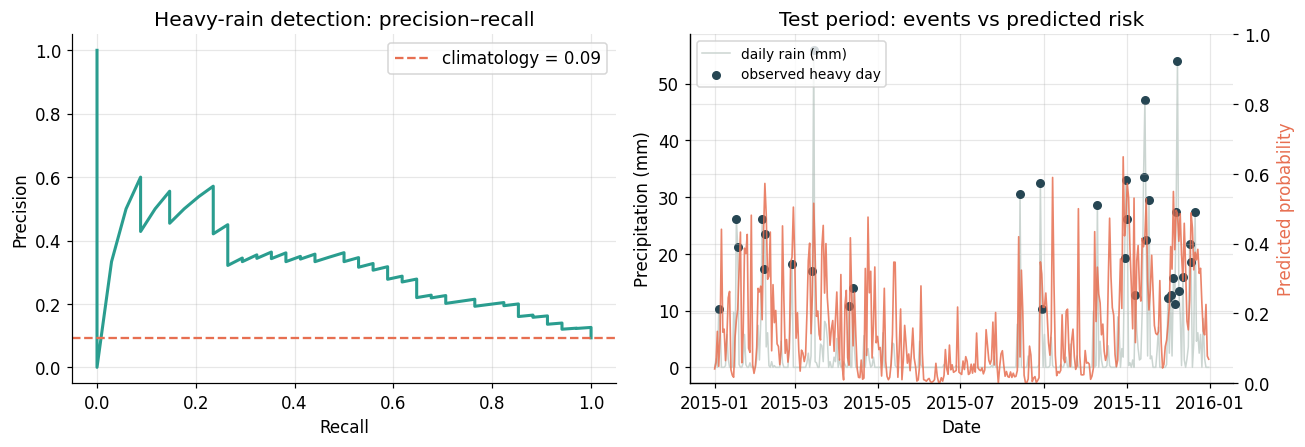

In [5]:
from sklearn.metrics import precision_recall_curve

feat["heavy"] = (feat.precipitation > 10).astype(int)   # target B: flood-relevant heavy day
ytr_h, yte_h = feat.heavy.iloc[:split], feat.heavy.iloc[split:]

clf_h = RandomForestClassifier(n_estimators=500, min_samples_leaf=3,
                               class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1)
clf_h.fit(Xtr, ytr_h)
proba_h = clf_h.predict_proba(Xte)[:, 1]

base_h = yte_h.mean()
print(f"Heavy-day base rate (climatology) : {base_h:.1%}")
print(f"ROC AUC                            : {roc_auc_score(yte_h, proba_h):.3f}")
print(f"Average precision (PR AUC)         : {average_precision_score(yte_h, proba_h):.3f}"
      f"  ->  {average_precision_score(yte_h, proba_h)/base_h:.1f}x lift over climatology")

prec, rec, _ = precision_recall_curve(yte_h, proba_h)
test_dates = feat.date.iloc[split:].values
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
ax[0].plot(rec, prec, color="#2a9d8f", lw=2)
ax[0].axhline(base_h, color="#e76f51", ls="--", label=f"climatology = {base_h:.2f}")
ax[0].set(xlabel="Recall", ylabel="Precision", title="Heavy-rain detection: precision–recall")
ax[0].legend()
ax[1].plot(test_dates, feat.precipitation.iloc[split:], color="#cbd5d1", lw=1, label="daily rain (mm)")
hit = feat.iloc[split:][yte_h.values == 1]
ax[1].scatter(hit.date, hit.precipitation, s=24, color="#264653", zorder=3, label="observed heavy day")
ax2 = ax[1].twinx()
ax2.plot(test_dates, proba_h, color="#e76f51", lw=1.1, alpha=0.85, label="predicted P(heavy)")
ax2.set_ylabel("Predicted probability", color="#e76f51"); ax2.set_ylim(0, 1)
ax[1].set(xlabel="Date", ylabel="Precipitation (mm)", title="Test period: events vs predicted risk")
ax[1].legend(loc="upper left", fontsize=9)
fig.tight_layout(); fig.savefig(ASSETS / "fig3_heavy_rain.png", bbox_inches="tight"); plt.show()

## 5. Opening the black box

A model that predicts well but cannot be interrogated is of little teaching or scientific
value. **Permutation importance** asks how much skill is lost when each feature is shuffled;
**partial dependence** shows the shape of the learned response for the heavy-rain detector.

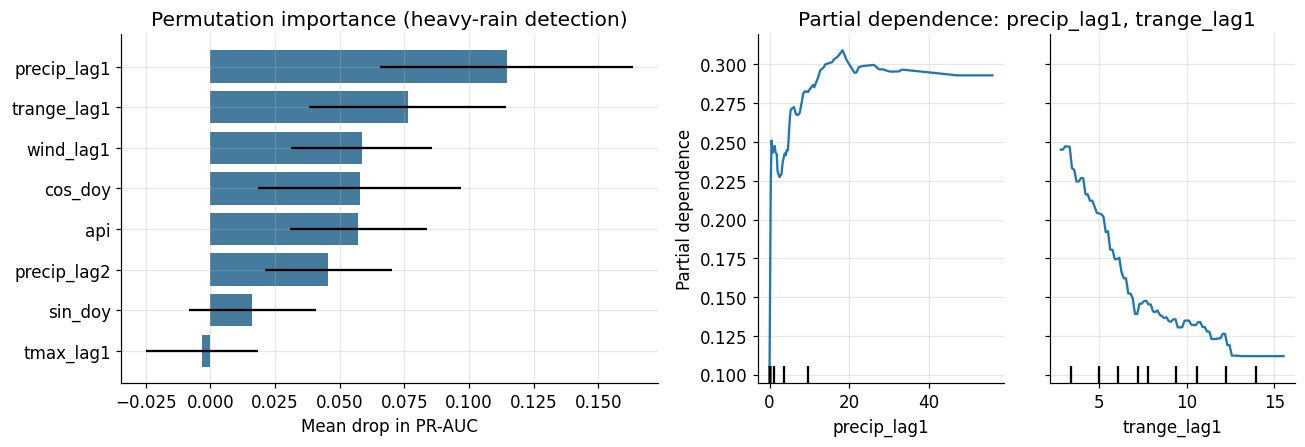

Most informative drivers: [np.str_('precip_lag1'), np.str_('trange_lag1')]


In [6]:
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

imp = permutation_importance(clf_h, Xte, yte_h, scoring="average_precision",
                             n_repeats=20, random_state=RANDOM_STATE, n_jobs=-1)
order = imp.importances_mean.argsort()

fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
ax[0].barh(np.array(FEATURES)[order], imp.importances_mean[order],
           xerr=imp.importances_std[order], color="#457b9d")
ax[0].set(title="Permutation importance (heavy-rain detection)", xlabel="Mean drop in PR-AUC")
top2 = list(np.array(FEATURES)[order][-2:][::-1])
PartialDependenceDisplay.from_estimator(clf_h, Xte, top2, ax=ax[1])
ax[1].set_title(f"Partial dependence: {', '.join(top2)}")
fig.tight_layout(); fig.savefig(ASSETS / "fig4_explainability.png", bbox_inches="tight"); plt.show()
print("Most informative drivers:", top2)

### The honest counterpoint: exact magnitude is *not* skilfully predictable

For contrast, a regressor trained to predict the **exact daily total** reaches only
**NSE ≈ 0.08** on the test set — barely better than predicting the climatological mean. That
asymmetry is not a failure to hide; it is the scientific message. *Occurrence and exceedance*
carry a learnable signal from antecedent state and seasonality, while the *precise amount* of a
given storm is dominated by sub-daily, convective processes a daily model cannot see. This is
exactly why event-based, threshold-driven sampling — the backbone of my isotope and
transit-time fieldwork — remains indispensable.

In [7]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

def nse(obs, sim):
    return 1 - np.sum((sim - obs)**2) / np.sum((obs - obs.mean())**2)

reg = RandomForestRegressor(n_estimators=500, min_samples_leaf=5,
                            random_state=RANDOM_STATE, n_jobs=-1)
reg.fit(Xtr, np.log1p(feat.precipitation.iloc[:split]))
pred_mm = np.expm1(reg.predict(Xte))
obs_mm = feat.precipitation.iloc[split:].values
print(f"Exact daily-total regression -> NSE = {nse(obs_mm, pred_mm):.3f} | "
      f"R^2 = {r2_score(obs_mm, pred_mm):.3f}  (occurrence is predictable; magnitude is not)")

Exact daily-total regression -> NSE = 0.080 | R^2 = 0.080  (occurrence is predictable; magnitude is not)


## 6. Honest limitations, and how to run this on a Taiwan station

**What this does *not* claim.** A single station, four years, and tree ensembles are a
*teaching baseline*, not an operational forecast. Daily rainfall magnitude is intrinsically
hard (note the modest NSE) — that honesty is the point. Natural next steps: more stations and
years, sequence models (LSTM/Transformer) on hourly data, probabilistic targets, and proper
cross-validation by hydrological year.

**Transfer to Taiwan.** The pipeline only needs a daily table with `date, precipitation,
temp_max, temp_min, wind`. The stub below shows the shape of a Central Weather Administration /
Water Resources Agency loader; drop in a station and *every cell above runs unchanged*.

In [8]:
def load_taiwan_station(station_id, start, end):
    '''Template for swapping in Taiwan open data (CWB/WRA).

    Implement ONE of:
      * CWB Open Data API  (https://opendata.cwa.gov.tw)  -> daily precip + temperature
      * WRA reservoir/rain-gauge open data (https://data.wra.gov.tw)
    and return a DataFrame with columns:
        ['date','precipitation','temp_max','temp_min','wind']
    Then call add_features(...) exactly as above.
    '''
    raise NotImplementedError("Plug in a CWB/WRA endpoint and an API token.")

# Example (pseudocode):
# df_tw = load_taiwan_station("467410", "2015-01-01", "2024-12-31")  # 467410 = Tainan station
# feat_tw = add_features(df_tw).dropna()
print("Pipeline is station-agnostic: replace load_weather() with load_taiwan_station().")

Pipeline is station-agnostic: replace load_weather() with load_taiwan_station().


## 7. Reproducibility

Fixed random seeds, a cached real dataset, and pinned library versions — so anyone, including
a hiring committee, can clone the repo and reproduce every number and figure above.

In [9]:
import sklearn, sys
print("python      ", sys.version.split()[0])
for m in (np, pd, sklearn):
    print(f"{m.__name__:<12}", m.__version__)
print("\nData source : NOAA GHCN daily observations via vega-datasets (BSD-3).")
print("Random seed :", RANDOM_STATE)

python       3.10.12
numpy        2.2.6
pandas       2.3.3
sklearn      1.7.2

Data source : NOAA GHCN daily observations via vega-datasets (BSD-3).
Random seed : 42
